# Neuron Model Atlas — 82 Years of Computational Neuroscience

**SC-NeuroCore v3.14** — Visual reference for 122 neuron models (1943–2026).

This notebook simulates representative models from each family
under identical step-current injection and plots their characteristic
voltage traces. A one-page guide to the model library.

| Family | Era | Examples | Dynamics |
|--------|-----|---------|----------|
| Integrate-and-fire | 1907–2022 | LIF, ALIF, GatedLIF, ExpIF | Threshold crossing |
| Biophysical | 1952–2005 | Hodgkin-Huxley, Morris-Lecar, Connor-Stevens | Ion channel gating |
| Phenomenological | 1961–2003 | FitzHugh-Nagumo, Izhikevich, AdEx | Reduced dynamics |
| Bursting | 1984–2005 | Hindmarsh-Rose, Chay, Pinsky-Rinzel | Multi-timescale |
| Hardware | 2011–2024 | Loihi2, TrueNorth, SpiNNaker | Digital emulation |
| AI-optimised | 2026 | ArcaneNeuron, AttentionGated, MetaPlastic | Self-referential |

> © 1998–2026 Miroslav Šotek. All rights reserved.  
> License: GNU AFFERO GENERAL PUBLIC LICENSE v3 | Commercial Licensing Available  
> Contact: www.anulum.li | protoscience@anulum.li

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sc_neurocore.neurons.equation_builder import EquationNeuron
from sc_neurocore import StochasticLIFNeuron

print("SC-NeuroCore neuron atlas")

SC-NeuroCore neuron atlas


## Building the Atlas

We define each model as an `EquationNeuron` from ODE strings —
the same representation used for FPGA compilation. Each model
receives a step current at t=100 ms.

In [2]:
models = {
    "LIF (Lapicque 1907)": EquationNeuron(
        equations={"v": "-(v - v_rest) / tau + I"},
        parameters={"v_rest": 0.0, "tau": 20.0},
        state={"v": 0.0},
        threshold="v > 1.0",
        reset={"v": "0.0"},
        dt=0.1,
    ),
    "ExpIF (Fourcaud-Trocmé 2003)": EquationNeuron(
        equations={"v": "-(v - v_rest) / tau + delta_T * exp((v - v_T) / delta_T) / tau + I"},
        parameters={"v_rest": -65.0, "tau": 20.0, "delta_T": 2.0, "v_T": -50.0},
        state={"v": -65.0},
        threshold="v > -30",
        reset={"v": "-65.0"},
        dt=0.1,
    ),
    "AdEx (Brette & Gerstner 2005)": EquationNeuron(
        equations={
            "v": "-(v - v_rest) / tau + delta_T * exp((v - v_T) / delta_T) / tau - w + I",
            "w": "(a * (v - v_rest) - w) / tau_w",
        },
        parameters={"v_rest": -65.0, "tau": 20.0, "delta_T": 2.0,
                    "v_T": -50.0, "a": 0.01, "tau_w": 100.0},
        state={"v": -65.0, "w": 0.0},
        threshold="v > -30",
        reset={"v": "-65.0", "w": "w + 0.5"},
        dt=0.1,
    ),
    "Izhikevich RS (2003)": EquationNeuron(
        equations={
            "v": "0.04 * v**2 + 5 * v + 140 - u + I",
            "u": "a * (b * v - u)",
        },
        parameters={"a": 0.02, "b": 0.2},
        state={"v": -65.0, "u": -14.0},
        threshold="v > 30",
        reset={"v": "-65", "u": "u + 8"},
        dt=0.5,
    ),
    "Izhikevich IB (2003)": EquationNeuron(
        equations={
            "v": "0.04 * v**2 + 5 * v + 140 - u + I",
            "u": "a * (b * v - u)",
        },
        parameters={"a": 0.02, "b": 0.2},
        state={"v": -70.0, "u": -14.0},
        threshold="v > 30",
        reset={"v": "-55", "u": "u + 4"},
        dt=0.5,
    ),
    "Izhikevich CH (2003)": EquationNeuron(
        equations={
            "v": "0.04 * v**2 + 5 * v + 140 - u + I",
            "u": "a * (b * v - u)",
        },
        parameters={"a": 0.02, "b": 0.2},
        state={"v": -70.0, "u": -14.0},
        threshold="v > 30",
        reset={"v": "-50", "u": "u + 2"},
        dt=0.5,
    ),
    "Izhikevich FS (2003)": EquationNeuron(
        equations={
            "v": "0.04 * v**2 + 5 * v + 140 - u + I",
            "u": "a * (b * v - u)",
        },
        parameters={"a": 0.1, "b": 0.2},
        state={"v": -65.0, "u": -14.0},
        threshold="v > 30",
        reset={"v": "-65", "u": "u + 2"},
        dt=0.5,
    ),
    "FitzHugh-Nagumo (1961)": EquationNeuron(
        equations={
            "v": "v - v**3 / 3 - w + I",
            "w": "0.08 * (v + 0.7 - 0.8 * w)",
        },
        state={"v": -1.0, "w": -0.5},
        threshold="v > 1.0",
        reset={"v": "-1.0"},
        dt=0.05,
    ),
    "Morris-Lecar (1981)": EquationNeuron(
        equations={
            "v": "(-g_L * (v - v_L) - g_Ca * 0.5 * (1 + tanh((v - v1) / v2)) * (v - v_Ca) - g_K * w * (v - v_K) + I) / C",
            "w": "(0.5 * (1 + tanh((v - v3) / v4)) - w) / (1.0 / (0.04 * (1 + tanh((v - v3) / v4)) + 0.001))",
        },
        parameters={"g_L": 2.0, "v_L": -60.0, "g_Ca": 4.0, "v_Ca": 120.0,
                    "g_K": 8.0, "v_K": -80.0, "v1": -1.2, "v2": 18.0,
                    "v3": 12.0, "v4": 17.4, "C": 20.0},
        state={"v": -60.0, "w": 0.01},
        threshold="v > 20",
        reset={"v": "-60.0"},
        dt=0.05,
    ),
    "Hindmarsh-Rose (1984)": EquationNeuron(
        equations={
            "x": "y - a * x**3 + b * x**2 - z + I",
            "y": "c - d * x**2 - y",
            "z": "r * (s * (x - x_r) - z)",
        },
        parameters={"a": 1.0, "b": 3.0, "c": 1.0, "d": 5.0,
                    "r": 0.005, "s": 4.0, "x_r": -1.6},
        state={"x": -1.5, "y": -10.0, "z": 2.0},
        threshold="x > 1.0",
        reset={"x": "-1.5"},
        dt=0.05,
    ),
    "Resonate-and-fire (Izhikevich 2001)": EquationNeuron(
        equations={
            "v": "b * v - w + I",
            "w": "v + b * w",
        },
        parameters={"b": 0.98},
        state={"v": 0.0, "w": 0.0},
        threshold="v > 1.0",
        reset={"v": "0.0", "w": "0.0"},
        dt=0.5,
    ),
    "Quadratic IF (Latham 2000)": EquationNeuron(
        equations={"v": "v**2 + I"},
        state={"v": -0.5},
        threshold="v > 1.0",
        reset={"v": "-1.0"},
        dt=0.1,
    ),
}

print(f"Atlas: {len(models)} models ready")

Atlas: 12 models ready


## Voltage Traces Under Step Current

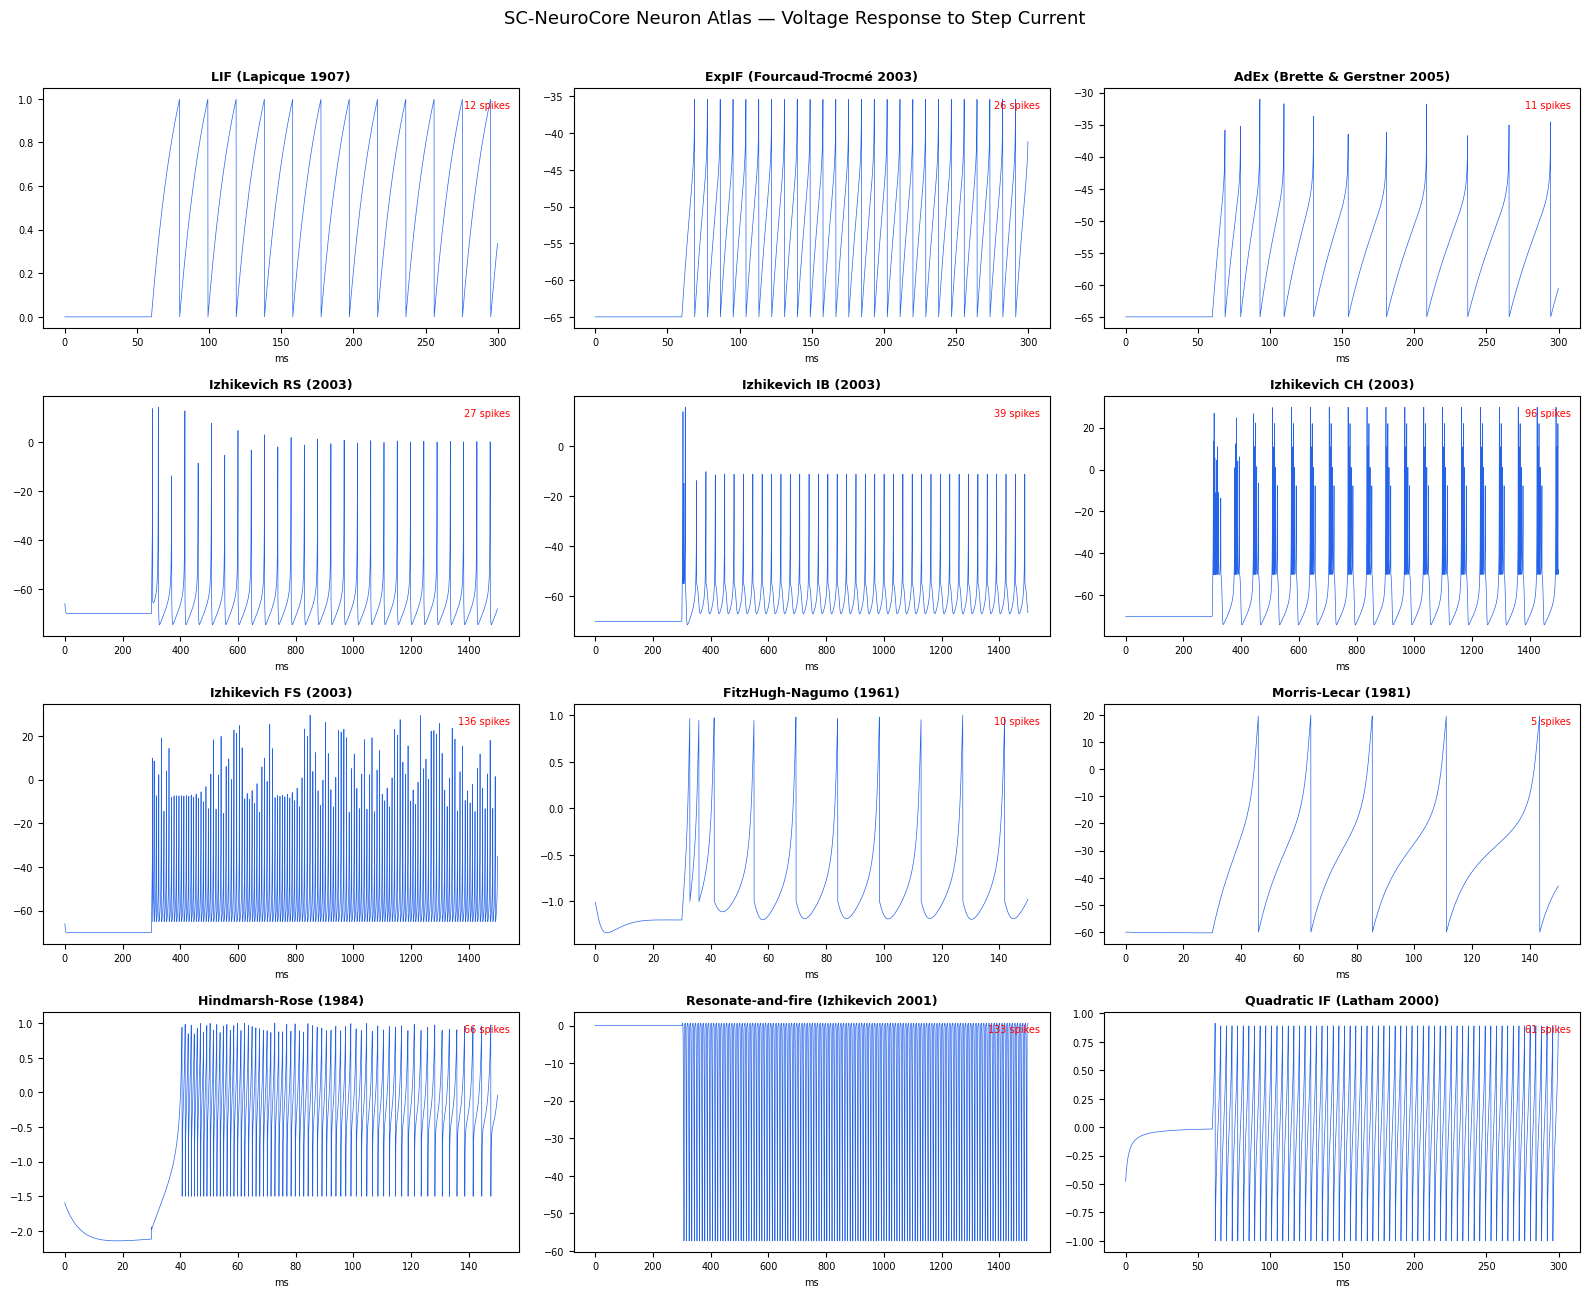

In [3]:
n_models = len(models)
n_cols = 3
n_rows = (n_models + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 3.2 * n_rows))
axes = axes.flatten()

# Current injection profiles per model (tuned to produce spikes)
I_map = {
    "LIF (Lapicque 1907)": 0.08,
    "ExpIF (Fourcaud-Trocmé 2003)": 3.0,
    "AdEx (Brette & Gerstner 2005)": 3.0,
    "Izhikevich RS (2003)": 10.0,
    "Izhikevich IB (2003)": 10.0,
    "Izhikevich CH (2003)": 10.0,
    "Izhikevich FS (2003)": 10.0,
    "FitzHugh-Nagumo (1961)": 0.5,
    "Morris-Lecar (1981)": 100.0,
    "Hindmarsh-Rose (1984)": 3.5,
    "Resonate-and-fire (Izhikevich 2001)": 0.15,
    "Quadratic IF (Latham 2000)": 0.3,
}

for idx, (name, neuron) in enumerate(models.items()):
    ax = axes[idx]
    neuron.state = dict(neuron.initial_state)  # reset

    T = 3000
    dt = neuron.dt
    I_amp = I_map.get(name, 5.0)
    var_name = list(neuron.equations.keys())[0]  # first state variable (voltage)

    trace = np.zeros(T)
    spikes = []
    for t in range(T):
        I = I_amp if t > T // 5 else 0.0
        spike = neuron.step(I=I)
        trace[t] = neuron.state[var_name]
        if spike:
            spikes.append(t)

    time_ms = np.arange(T) * dt
    ax.plot(time_ms, trace, linewidth=0.5, color="#2563EB")
    ax.set_title(name, fontsize=9, fontweight="bold")
    ax.set_xlabel("ms", fontsize=7)
    ax.tick_params(labelsize=7)

    # Annotate spike count
    n_sp = len(spikes)
    if n_sp > 0:
        ax.annotate(f"{n_sp} spikes", xy=(0.98, 0.95), xycoords="axes fraction",
                    ha="right", va="top", fontsize=7, color="red")

# Hide unused axes
for idx in range(n_models, len(axes)):
    axes[idx].set_visible(False)

plt.suptitle("SC-NeuroCore Neuron Atlas — Voltage Response to Step Current",
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## Firing Pattern Classification

| Pattern | Models | Distinguishing feature |
|---------|--------|----------------------|
| Regular spiking | LIF, Izhikevich RS | Constant ISI under constant drive |
| Fast spiking | Izhikevich FS | Short ISI, no adaptation |
| Intrinsic bursting | Izhikevich IB | Initial burst → regular |
| Chattering | Izhikevich CH | Rhythmic burst clusters |
| Tonic bursting | Hindmarsh-Rose | Slow variable modulates burst envelope |
| Subthreshold oscillation | FHN, Morris-Lecar | Damped/sustained limit cycle |
| Resonance | Resonate-and-fire | Frequency-selective input amplification |
| Spike frequency adaptation | AdEx | Decreasing rate with sustained input |

All 122 models are runnable. This atlas shows 12 representatives;
use `04_neuron_explorer.ipynb` for interactive exploration of the
full library.